HANDLING OUTLIERS

A) Detecting outliers using z-score

In [1]:
import pandas as pd
df=pd.read_csv('placement.csv')

In [3]:
df.sample(10)

,Unnamed: 0,cgpa,iq,placement
13,13,6.4,116.0,1
0,0,6.8,123.0,1
80,80,4.9,196.0,0
77,77,7.3,50.0,1
28,28,5.2,90.0,0
19,19,5.2,132.0,0
47,47,5.2,161.0,0
89,89,4.9,151.0,0
45,45,6.0,66.0,1
58,58,8.0,79.0,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [5]:
df.isnull().sum()

Unnamed: 0    0
cgpa          0
iq            0
placement     0
dtype: int64

<Axes: ylabel='Density'>

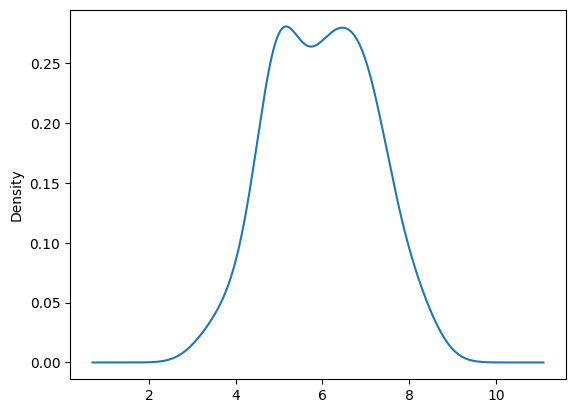

In [6]:
import matplotlib.pyplot as plt
df['cgpa'].plot(kind='kde')

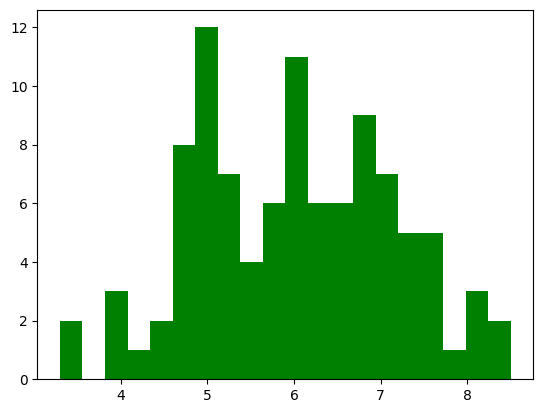

In [ ]:
plt.hist(df['cgpa'], bins=20,color='Green')
plt.show()

In [9]:
print(f'Mean:{df["cgpa"].mean()}')
print(f'STD:{df["cgpa"].std()}')

Mean:5.9910000000000005
STD:1.1436336737775692


In [11]:
#Manual implemetation
#Z-score = (Xi-mu)/sigma

df["Z-Score"]=(df['cgpa']-df['cgpa'].mean())/df['cgpa'].std()
df[['cgpa','Z-Score']].head(10)

,cgpa,Z-Score
0,6.8,0.707394
1,5.9,-0.079571
2,5.3,-0.604214
3,7.4,1.232038
4,5.8,-0.167012
5,7.1,0.969716
6,5.7,-0.254452
7,5.0,-0.866536
8,6.1,0.095310
9,5.1,-0.779096


In [13]:
#Finding Outlier
outlier=df[df['Z-Score'].abs()>3]
print(f'outliers are:{outlier}')

outliers are:Empty DataFrame
Columns: [Unnamed: 0, cgpa, iq, placement, Z-Score]
Index: []


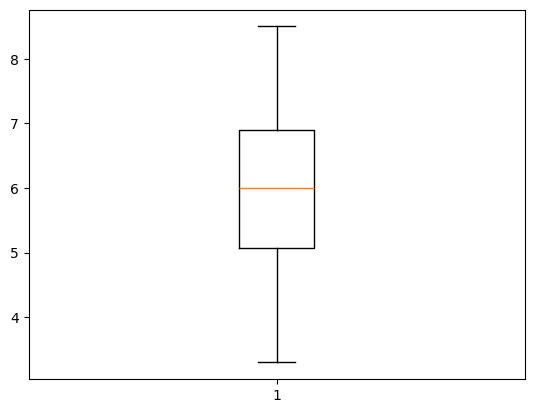

In [14]:
import matplotlib.pyplot as plt

plt.boxplot(df['cgpa'])
plt.show()

In [15]:
import pandas as pd
df=pd.read_csv('train.csv')

df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
80,81,0,3,"Waelens, Mr. Achille",male,22.0,0,0,345767,9.0000,NaN,S
220,221,1,3,"Sunderland, Mr. Victor Francis",male,16.0,0,0,SOTON/OQ 392089,8.0500,NaN,S
32,33,1,3,"Glynn, Miss. Mary Agatha",female,NaN,0,0,335677,7.7500,NaN,Q
93,94,0,3,"Dean, Mr. Bertram Frank",male,26.0,1,2,C.A. 2315,20.5750,NaN,S
628,629,0,3,"Bostandyeff, Mr. Guentcho",male,26.0,0,0,349224,7.8958,NaN,S
641,642,1,1,"Sagesser, Mlle. Emma",female,24.0,0,0,PC 17477,69.3000,B35,C
181,182,0,2,"Pernot, Mr. Rene",male,NaN,0,0,SC/PARIS 2131,15.0500,NaN,C
29,30,0,3,"Todoroff, Mr. Lalio",male,NaN,0,0,349216,7.8958,NaN,S
559,560,1,3,"de Messemaeker, Mrs. Guillaume Joseph (Emma)",female,36.0,1,0,345572,17.4000,NaN,S
362,363,0,3,"Barbara, Mrs. (Catherine David)",female,45.0,0,1,2691,14.4542,NaN,C


In [16]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [18]:
num_df=df.select_dtypes(include=['number'])

In [19]:
num_df.sample(5)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
653,654,1,3,NaN,0,0,7.8292
179,180,0,3,36.0,0,0,0.0000
268,269,1,1,58.0,0,1,153.4625
620,621,0,3,27.0,1,0,14.4542
102,103,0,1,21.0,0,1,77.2875


In [20]:
num_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Age            177
SibSp            0
Parch            0
Fare             0
dtype: int64

In [22]:
num_df['Z-Score']=(num_df['Age']-num_df['Age'].mean())/num_df['Age'].std()

In [25]:
num_df[['Age','Z-Score']].head(5)

,Age,Z-Score
0,22.0,-0.530005
1,38.0,0.571430
2,26.0,-0.254646
3,35.0,0.364911
4,35.0,0.364911


In [26]:
outliers=(num_df['Z-Score'].abs()>3)

In [31]:
outliers.sum()


np.int64(2)

In [32]:
num_df[outliers]

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Z-Score
630,631,1,1,80.0,0,0,30.000,3.462699
851,852,0,3,74.0,0,0,7.775,3.049660


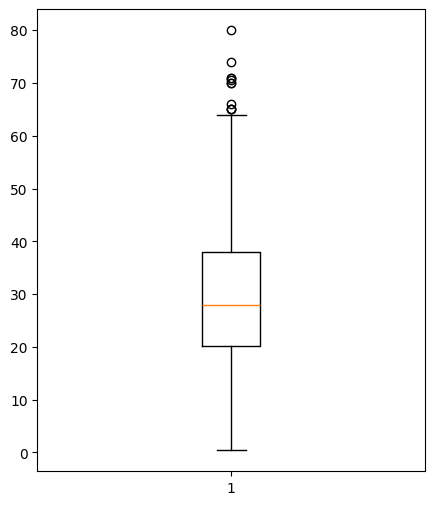

In [45]:
plt.figure(figsize=(5,6))
plt.boxplot(num_df['Age'].dropna())
plt.show()

B) Detecting outliers using IQR

In [47]:
import pandas as pd

df=pd.read_csv('train.csv')

df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
601,602,0,3,"Slabenoff, Mr. Petco",male,NaN,0,0,349214,7.8958,NaN,S
237,238,1,2,"Collyer, Miss. Marjorie ""Lottie""",female,8.0,0,2,C.A. 31921,26.2500,NaN,S
358,359,1,3,"McGovern, Miss. Mary",female,NaN,0,0,330931,7.8792,NaN,Q
768,769,0,3,"Moran, Mr. Daniel J",male,NaN,1,0,371110,24.1500,NaN,Q
298,299,1,1,"Saalfeld, Mr. Adolphe",male,NaN,0,0,19988,30.5000,C106,S


In [48]:
num_df=df.select_dtypes(include=['number'])
num_df.head(5)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [49]:
num_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Age            177
SibSp            0
Parch            0
Fare             0
dtype: int64

In [50]:
#First remove missing values
age=num_df['Age'].dropna()

In [51]:
Q1=age.quantile(0.25)
Q2=age.quantile(0.5)
Q3=age.quantile(0.75)

print("Q1:",Q1)
print("Q2:",Q2)
print("Q3:",Q3)

Q1: 20.125
Q2: 28.0
Q3: 38.0


In [53]:
IQR=Q3-Q1
print("IQR is:",IQR)

IQR is: 17.875


In [56]:
Lower_limit=Q1-1.5*IQR
Upper_limit=Q3+1.5*IQR
print(f'Lower Limit is:{Lower_limit}')
print(f'Upper Limit is:{Upper_limit}')

Lower Limit is:-6.6875
Upper Limit is:64.8125


In [57]:
outliers=df[(df['Age']<Lower_limit) | (df['Age']>Upper_limit)]

print(f'Numer of Outliers are:{outliers.shape[0]}')

Numer of Outliers are:11


In [58]:
len(outliers)

11

In [62]:
print(outliers['Age'])

33     66.0
54     65.0
96     71.0
116    70.5
280    65.0
456    65.0
493    71.0
630    80.0
672    70.0
745    70.0
851    74.0
Name: Age, dtype: float64


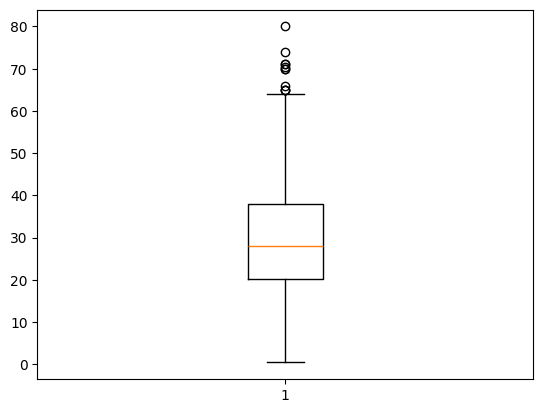

In [59]:
import matplotlib.pyplot as plt
plt.boxplot(age)
plt.show()

REMOVING OUTLIERS

A) Trimming

<Axes: ylabel='Density'>

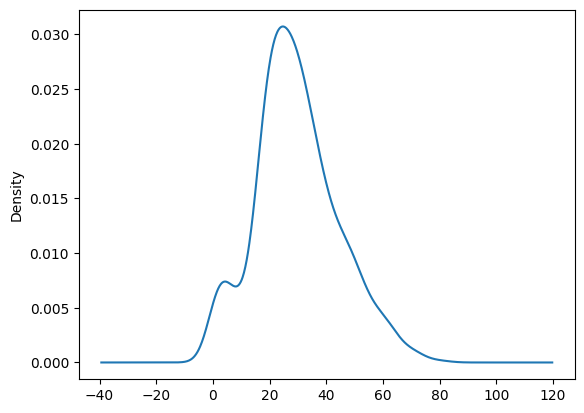

In [69]:
df['Age'].plot(kind='kde')

In [71]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [72]:
df_trimmed=df[(df['Age']>=Lower_limit) & (df['Age']<=Upper_limit)]

In [74]:
print(f'Original Shape:{df.shape}')
print(f'Trimmed Shape:{df_trimmed.shape}')

Original Shape:(891, 12)
Trimmed Shape:(880, 12)


B)TRANSFORMATION

1) LOG TRANSFORMATION

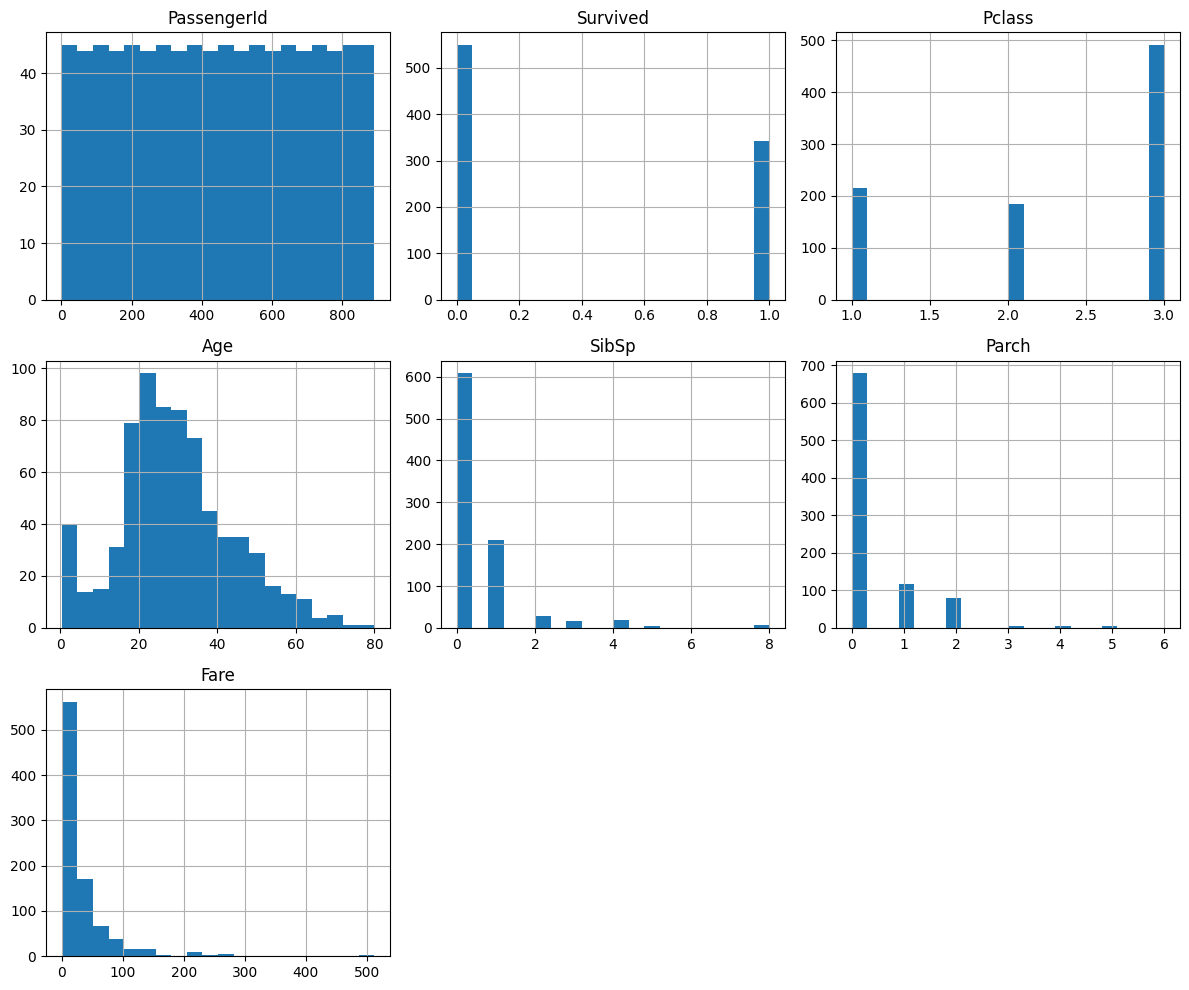

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('train.csv')

#NOTE: LT is used when there is rigt skew.
df.hist(figsize=(12,10),bins=20)
plt.tight_layout()
plt.show()


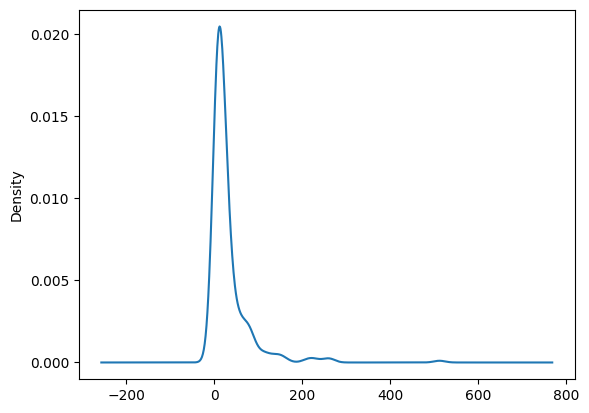

In [80]:
#From the graph plotted above we can understand that Fare is right skewed so we chose this for LT
df['Fare'].plot(kind='kde')
plt.show()

In [81]:
#we have to check wether the column (FARE) contains values <= Zero
#Because log 0 will be -INF

print(df['Fare'].min())

0.0


In [82]:
df['Fare_Log']=np.log1p(df['Fare'])

In [84]:
df[["Fare",'Fare_Log']].head(10)

,Fare,Fare_Log
0,7.2500,2.110213
1,71.2833,4.280593
2,7.9250,2.188856
3,53.1000,3.990834
4,8.0500,2.202765
5,8.4583,2.246893
6,51.8625,3.967694
7,21.0750,3.094446
8,11.1333,2.495954
9,30.0708,3.436268


Text(0.5, 1.0, 'Log Transformed Fare')

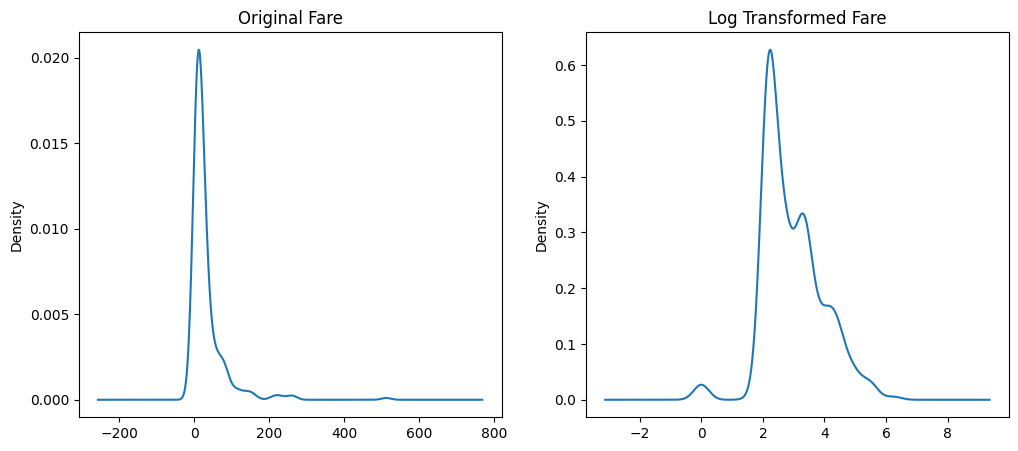

In [86]:
#Compare the distribution
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df['Fare'].plot(kind='kde')
plt.title("Original Fare")

plt.subplot(1,2,2)
df["Fare_Log"].plot(kind="kde")
plt.title("Log Transformed Fare")

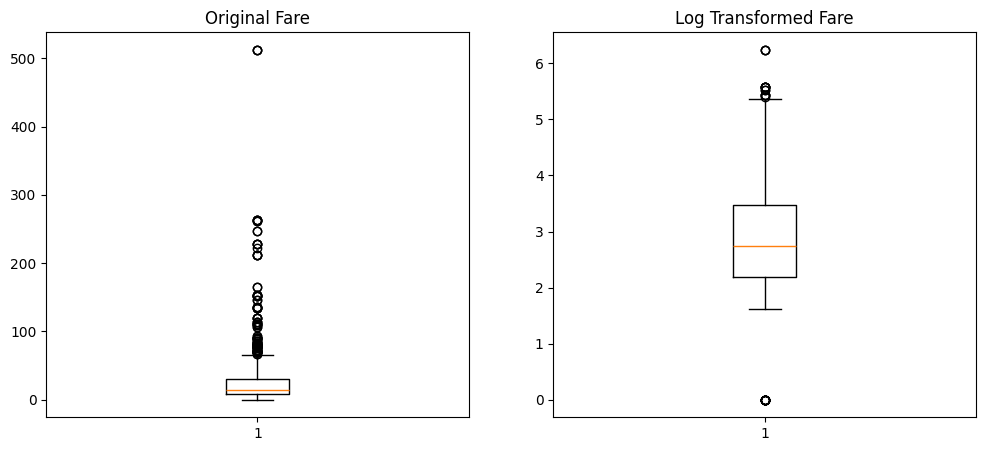

In [88]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.boxplot(df['Fare'])
plt.title("Original Fare")

plt.subplot(1,2,2)
plt.boxplot(df['Fare_Log'])
plt.title("Log Transformed Fare")

plt.show()

2) SQUARE ROOT TRANSFORMATION

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('train.csv')

#Here also we use FARE column because it is the right skew column
df['Fare_sqrt']=np.sqrt(df['Fare'])

In [90]:
df[['Fare','Fare_sqrt']].sample(5)

,Fare,Fare_sqrt
160,16.1000,4.012481
146,7.7958,2.792096
334,133.6500,11.560709
195,146.5208,12.104578
693,7.2250,2.687936


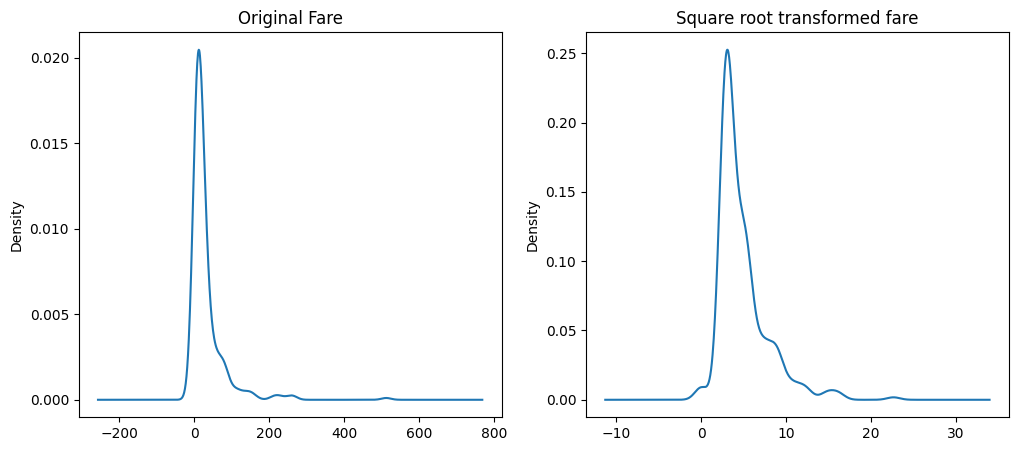

In [91]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df['Fare'].plot(kind='kde')
plt.title("Original Fare")

plt.subplot(1,2,2)
df['Fare_sqrt'].plot(kind='kde')
plt.title("Square root transformed fare")

plt.show()

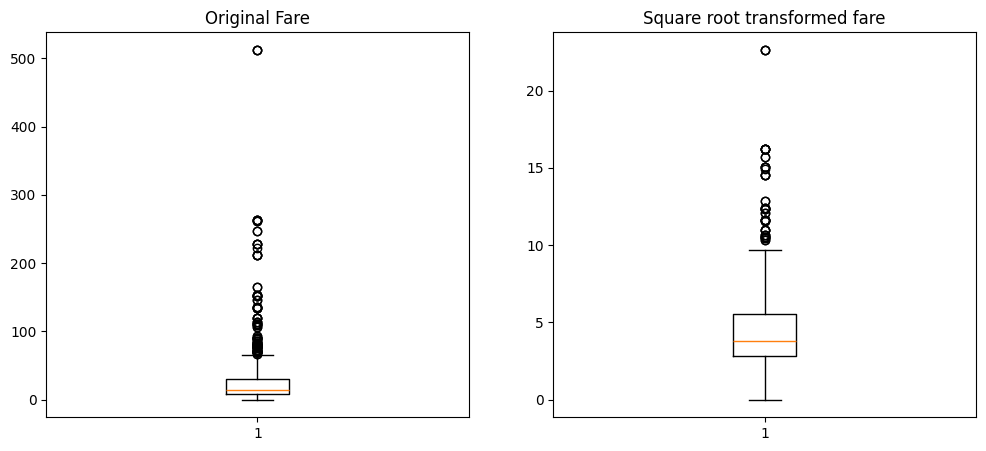

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.boxplot(df['Fare'])
plt.title("Original Fare")

plt.subplot(1,2,2)
plt.boxplot(df['Fare_sqrt'])
plt.title("Square root transformed fare")

plt.show()

In [ ]:
#NOTE:Square root transformation reduce the skewness but not as much as log transformation

CAPPING AND FLOORING


In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv('train.csv')


In [95]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [96]:
df['Age'].isnull().sum()

np.int64(177)

In [97]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [98]:
df['Age'].isnull().sum()

np.int64(0)

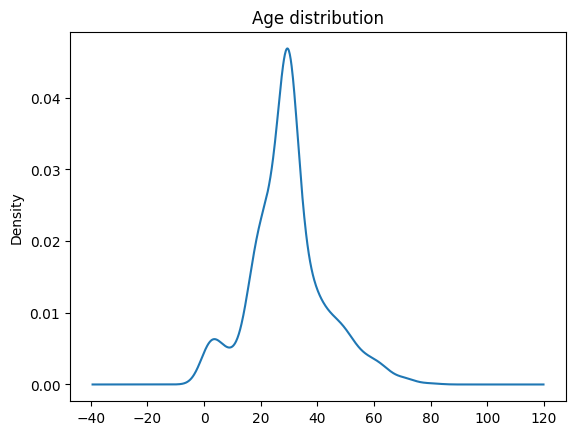

In [99]:
df['Age'].plot(kind='kde')
plt.title('Age distribution')
plt.show()

In [100]:
Q1=df['Age'].quantile(0.25)
Q3=df['Age'].quantile(0.75)

IQR=Q3-Q1

Lower_Limit=Q1-1.5*IQR
Upper_Limit=Q3+1.5*IQR

print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)

print(f'Lower_limit :{Lower_Limit}')
print(f'Upper_limit:{Upper_Limit}')

Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower_limit :2.5
Upper_limit:54.5


In [101]:
Outliers=df[(df['Age']<Lower_Limit) | (df["Age"]>Upper_Limit)]
print(Outliers["Age"])

7       2.00
11     58.00
15     55.00
16      2.00
33     66.00
       ...  
827     1.00
829    62.00
831     0.83
851    74.00
879    56.00
Name: Age, Length: 66, dtype: float64


In [109]:
len(Outliers['Age'])


66

In [110]:
df_capped=df.copy()

In [ ]:
#Apply Flooring
df_capped.loc[df_capped['Age']<Lower_Limit,'Age']=Lower_Limit
#Apply Capping
df_capped.loc[df_capped['Age']>Upper_Limit,'Age']=Upper_Limit

In [115]:
Outliers_after=df_capped[(df_capped['Age']<Lower_Limit) | (df_capped['Age']>Upper_Limit)]

In [116]:
print(len(Outliers_after))

0


In [119]:
print(f'Original Shape:{df.shape}')
print(f'Capped Shape:{df_capped.shape}')

Original Shape:(891, 12)
Capped Shape:(891, 12)


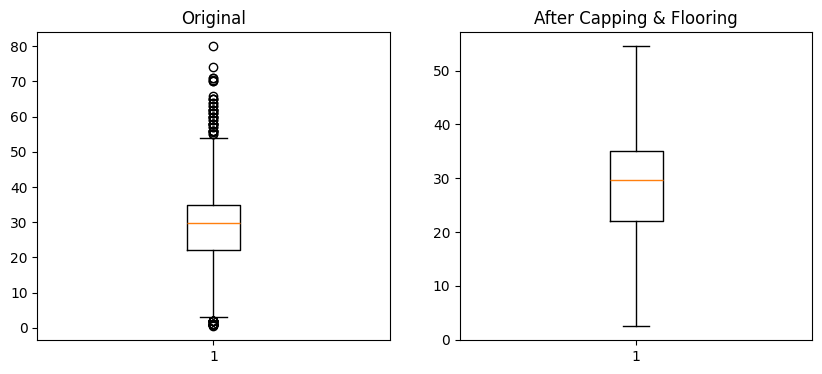

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.boxplot(df['Age'])
plt.title("Original")

plt.subplot(1,2,2)
plt.boxplot(df_capped['Age'])
plt.title("After Capping & Flooring")

plt.show()

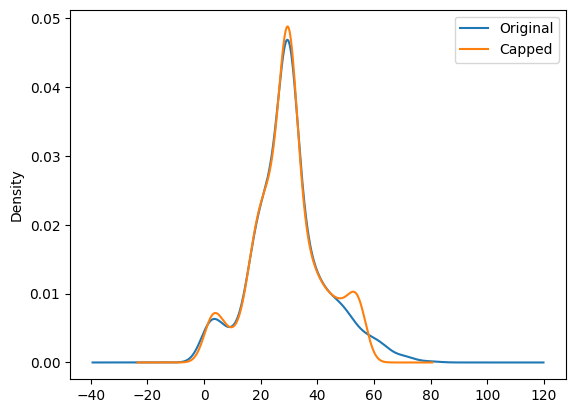

In [121]:
df['Age'].plot(kind='kde', label='Original')
df_capped['Age'].plot(kind='kde', label='Capped')

plt.legend()
plt.show()

In [ ]:
print("Original Mean:", df['Age'].mean())
print("Capped Mean:", df_capped['Age'].mean())

print("Original Variance:", df['Age'].var())
print("Capped Variance:", df_capped['Age'].var())

Original Mean: 29.69911764705882
Capped Mean: 29.376816861424704
Original Variance: 169.0523999372108
Capped Variance: 145.49269388417852


: 